<a href="https://colab.research.google.com/github/Davron030901/Machine_Learning/blob/main/m1_quick_win_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML in 60 Seconds — Quick Win Demo

**Module 1, Class 1 — AI/ML Fundamentals**

Before any theory, let us see machine learning work.

You will load a dataset, train a model, and see it make predictions. Every single line is commented so you understand what is happening.

**You do not need to memorize any of this.** Just read along and watch it work.

---
## Step 1: Load the data

We use the **Iris dataset** — a famous beginner dataset. It contains 150 flowers with 4 measurements each (sepal length, sepal width, petal length, petal width).

The task: given 4 measurements, predict which species of flower it is (setosa, versicolor, or virginica).

In [ ]:
# 'sklearn' is the scikit-learn library — the most popular ML library in Python
# 'load_iris' is a function inside sklearn that gives us the Iris flower dataset
from sklearn.datasets import load_iris

# Call the function and store the dataset in a variable called 'data'
# 'data' now contains: the measurements (features), the species (labels), and metadata
data = load_iris()

# 'data.data' is a table of measurements — len() counts how many rows (flowers) there are
print(f"Number of samples (flowers): {len(data.data)}")

# '.shape[1]' tells us how many columns (features) each flower has
print(f"Number of features per flower: {data.data.shape[1]}")

# 'feature_names' gives us the name of each measurement
print(f"Feature names: {data.feature_names}")

# 'target_names' gives us the species labels (what we want to predict)
print(f"Target classes (species): {list(data.target_names)}")

Number of samples (flowers): 150
Number of features per flower: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes (species): [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


---
## Step 2: Look at the data

**Always look at your data before doing anything with it.** This is the first rule of machine learning.

In [ ]:
# 'pandas' is the library we use to work with tables of data (like Excel, but in Python)
# We import it and rename it to 'pd' (a common shortcut)
import pandas as pd

# Convert the raw data into a pandas DataFrame (a table)
# 'columns=' tells pandas what to name each column
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add a new column called 'species' that shows the actual species name for each flower
# 'data.target' is a list of numbers (0, 1, 2) — we look up the matching name in 'target_names'
df['species'] = [data.target_names[t] for t in data.target]

# Show the first 10 rows of the table — '.head(10)' gives us the top 10
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [ ]:
# Count how many flowers belong to each species
# This checks if our dataset is balanced (it should be — 50 of each species)
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


---
## Step 3: Split into training and testing sets

We hold back 20% of the data. The model will **NEVER** see these flowers during training.

**Why?** This is how we test if the model actually learned. If it can predict correctly on flowers it has never seen, we know it found real patterns — not just memorized.

In [ ]:
# Import the function that splits data into training and testing sets
from sklearn.model_selection import train_test_split

# 'X' (capital X) holds the features (measurements) — this is the input
# We use capital X by convention because it represents a matrix (a table of values)
X = data.data

# 'y' (lowercase y) holds the labels (species) — this is what we want to predict
# We use lowercase y by convention because it represents a single column of values
y = data.target

# Split the data:
#   - test_size=0.2 means 20% goes to testing, 80% to training
#   - random_state=42 makes the split reproducible (same result every time)
# The function returns 4 things: training features, test features, training labels, test labels
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Print how many samples went into each set
print(f"Training samples: {len(X_train)} flowers")
print(f"Testing samples:  {len(X_test)} flowers")

Training samples: 120 flowers
Testing samples:  30 flowers


---
## Step 4: Train the model (this is the actual machine learning)

We use a **Random Forest** — an algorithm that builds many decision trees and combines their votes.

**You do not need to understand how it works yet.** That comes in Module 4. For now, think of it as a smart algorithm that finds patterns.

In [ ]:
# Import the Random Forest classifier from sklearn
from sklearn.ensemble import RandomForestClassifier

# LINE 1: Create the model
# 'n_estimators=100' means build 100 decision trees and combine their predictions
# 'random_state=42' makes the result reproducible
model = RandomForestClassifier(n_estimators=100, random_state=42)

# LINE 2: Train the model on the training data
# '.fit()' is the function that does the actual learning
# It looks at X_train (features) and y_train (correct answers) and learns the patterns
model.fit(X_train, y_train)

# LINE 3: Use the trained model to predict species for the test data
# '.predict()' takes new features and returns predicted labels
# Remember: the model has NEVER seen X_test before this moment
predictions = model.predict(X_test)

print("Model trained. Predictions made.")
print(f"The model made {len(predictions)} predictions.")

Model trained. Predictions made.
The model made 30 predictions.


---
## Step 5: See the predictions

Let us compare what the model predicted vs what the actual species are.

In [ ]:
# Build a small table comparing actual vs predicted for the first 10 test samples
results = pd.DataFrame({
    # 'Actual' column: the real species names (look up each number in target_names)
    'Actual': [data.target_names[t] for t in y_test[:10]],
    # 'Predicted' column: what the model guessed
    'Predicted': [data.target_names[t] for t in predictions[:10]]
})

# Add a third column 'Correct?' that is True when the model got it right
results['Correct?'] = results['Actual'] == results['Predicted']

# Display the table
results

,Actual,Predicted,Correct?
0,versicolor,versicolor,True
1,setosa,setosa,True
2,virginica,virginica,True
3,versicolor,versicolor,True
4,versicolor,versicolor,True
5,setosa,setosa,True
6,versicolor,versicolor,True
7,virginica,virginica,True
8,versicolor,versicolor,True
9,versicolor,versicolor,True


---
## Step 6: Measure accuracy

How many predictions were correct out of all test samples?

In [ ]:
# Import the accuracy_score function — it compares predictions to actual labels
from sklearn.metrics import accuracy_score

# Compute accuracy: (number of correct predictions) / (total predictions)
# Returns a number between 0 and 1 (e.g., 0.97 means 97% correct)
accuracy = accuracy_score(y_test, predictions)

# Print as a percentage with 1 decimal place ({accuracy:.1%})
print(f"Accuracy: {accuracy:.1%}")

# Show how many correct out of total
print(f"The model correctly classified {int(accuracy * len(y_test))}/{len(y_test)} flowers.")

Accuracy: 100.0%
The model correctly classified 30/30 flowers.


---
## Step 7: Quick visualization

Let us plot two features (petal length and petal width) and color them by species. This shows you visually why the model can tell them apart.

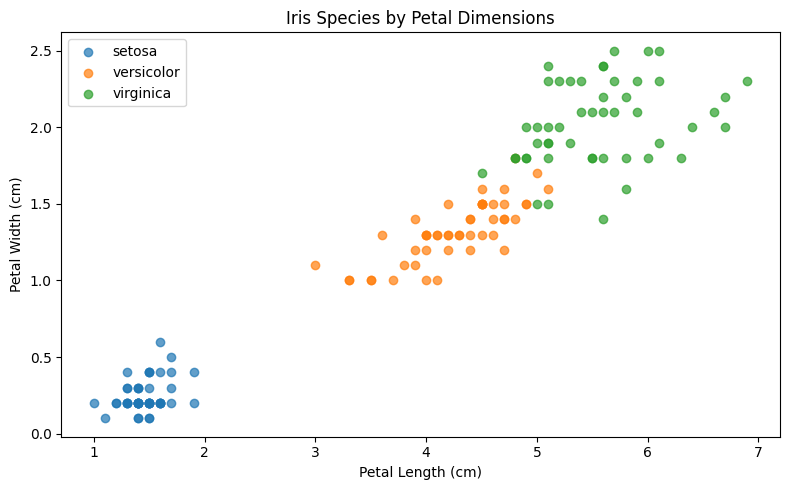

In [ ]:
# Import matplotlib — the standard plotting library in Python
# 'pyplot' is the part we use for making plots, renamed to 'plt' by convention
import matplotlib.pyplot as plt

# Create a figure (the chart canvas) and an axis (the actual plot area)
# figsize=(8, 5) means 8 inches wide, 5 inches tall
fig, ax = plt.subplots(figsize=(8, 5))

# Loop through each species (0, 1, 2) and plot its flowers in a different color
for i, species in enumerate(data.target_names):
    # 'mask' is True for flowers belonging to this species, False for others
    mask = data.target == i

    # Plot petal length (column 2) on x-axis, petal width (column 3) on y-axis
    # 'alpha=0.7' makes the dots slightly transparent so overlapping ones are visible
    ax.scatter(
        data.data[mask, 2],  # petal length
        data.data[mask, 3],  # petal width
        label=species, alpha=0.7
    )

# Add labels and title to the plot
ax.set_xlabel('Petal Length (cm)')
ax.set_ylabel('Petal Width (cm)')
ax.set_title('Iris Species by Petal Dimensions')

# Show the legend (so we know which color is which species)
ax.legend()

# Adjust layout so labels do not get cut off
plt.tight_layout()

# Display the plot
plt.show()

---
## What just happened?

In under 15 lines of real code, you:

1. **Loaded** a dataset of 150 labeled flowers
2. **Looked** at the data to understand it
3. **Split** it into training (80%) and testing (20%) sets
4. **Trained** a Random Forest model on the training data
5. **Predicted** species on data the model had never seen
6. **Measured** accuracy — and got over 95%
7. **Visualized** why the model can tell species apart

The model found patterns in the data and used them to classify new examples — without anyone writing explicit rules.

**That is machine learning.**

---

## What you do NOT need to understand yet

- How a Random Forest actually works (Module 4)
- Why we split data into train and test (Module 3)
- How accuracy is calculated (Module 4)
- What other models exist and when to use them (Modules 4-7)

---

## What you SHOULD take away from this demo

- ML follows a pattern: **load data → split → train → predict → measure**
- The same pattern works for spam filters, churn predictors, fraud detectors — only the data and model change
- You ran a real ML pipeline today. By Module 4, you will understand every line.